# Importación de los datos
Importación del dataset y lectura de sus características

In [1]:
import pandas as pd

DATOS = pd.read_csv("housing.csv")

### Descripción de las variables
1. **longitude:** A measure of how far west a house is; a higher value is farther west

2. **latitude:** A measure of how far north a house is; a higher value is farther north

3. **housingMedianAge:** Median age of a house within a block; a lower number is a newer building

4. **totalRooms:** Total number of rooms within a block

5. **totalBedrooms:** Total number of bedrooms within a block

6. **population:** Total number of people residing within a block

7. **households:** Total number of households (hogares, viviendas, domicilios), a group of people residing within a home unit, for a block

8. **medianIncome:** Median income for households within a block of houses (measured in tens of thousands of US Dollars)

9. **medianHouseValue:** Median house value for households within a block (measured in US Dollars)

10. **oceanProximity:** Location of the house w.r.t ocean/sea

In [2]:
DATOS.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
DATOS.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [4]:
DATOS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
DATOS.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
# 2 opciones: Eliminar los valores nulos o replazarlos con la media
data_non_null = DATOS.dropna()
data_non_null.info()

data_clean = DATOS.copy()
data_clean["total_bedrooms"] = data_clean["total_bedrooms"].fillna(value=data_clean["total_bedrooms"].mean())

#  Imprimimos para ver si la media cambia:
# Parece que 'total_bedrooms' no cambia (Si cambias los datos nulos por la media no alteras la media global)
# Pero otros valores si pueden cambiar (Si eliminas datos con 'total_bedrooms' nulos, realmente estás borrando
# esa fila de datos entera, por lo que eliminas ese valor del conteo de la media)
print("\ntotal_bedrooms:")
print(f"Media sin valores nulos:  {data_non_null["total_bedrooms"].mean()}")
print(f"Media imputando la media: {data_clean["total_bedrooms"].mean()}")

print("\nhousing_median_age:")
print(f"Media sin valores nulos:  {data_non_null["housing_median_age"].mean()}")
print(f"Media imputando la media: {data_clean["housing_median_age"].mean()}")

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB

total_bedrooms:
Media sin valores nulos:  537.8705525375618
Media imputando la media: 537.8705525375617

housing_median_age:
Media sin valores nulos:  28.633093525179856
Media imputando la media: 28.639486434108527


In [22]:
# Elijo quedarme con el dataframe sin datos nulos (y sin imputación de datos)
data = data_non_null.copy()

# Visualización de los datos (antes del procesamiento)
Mediante matplotlib y pandas

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# --- Dibujamos varios gráficos ---

def plotGraphs(data):
    """
    Crea 4 gráficos para el conjunto de datos especificado. No muestra datos muy relevantes, simplemente prueba a mostrar datos en diferentes plots
    """

    plt.style.use('_mpl-gallery')
    # Creamos los ejes de la figura
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))
    """
    nrows, ncols: Número de subplots en cada línea/columna 
    """

    # Dibujamos cada gráfico
    ax1.set_title("median_house_value")
    ax1.hist(data["median_house_value"], bins=50, linewidth=0.5, edgecolor="white")

    ax2.set_title("latitude vs longitude")
    ax2.scatter(np.array(data["latitude"]), np.array(data["longitude"]), color="green")

    ax3.set_title("median_house_value vs. total_rooms")
    ax3.scatter(
        np.array(data["median_house_value"]),
        np.array(data["total_rooms"])
    )

    ax4.set_title("ocean_proximity")
    x_categorica = data["ocean_proximity"].unique()
    y_categorica = np.array(data["ocean_proximity"].value_counts())
    ax4.bar(x_categorica, y_categorica, linewidth=0.5, color="blue")

    plt.show()

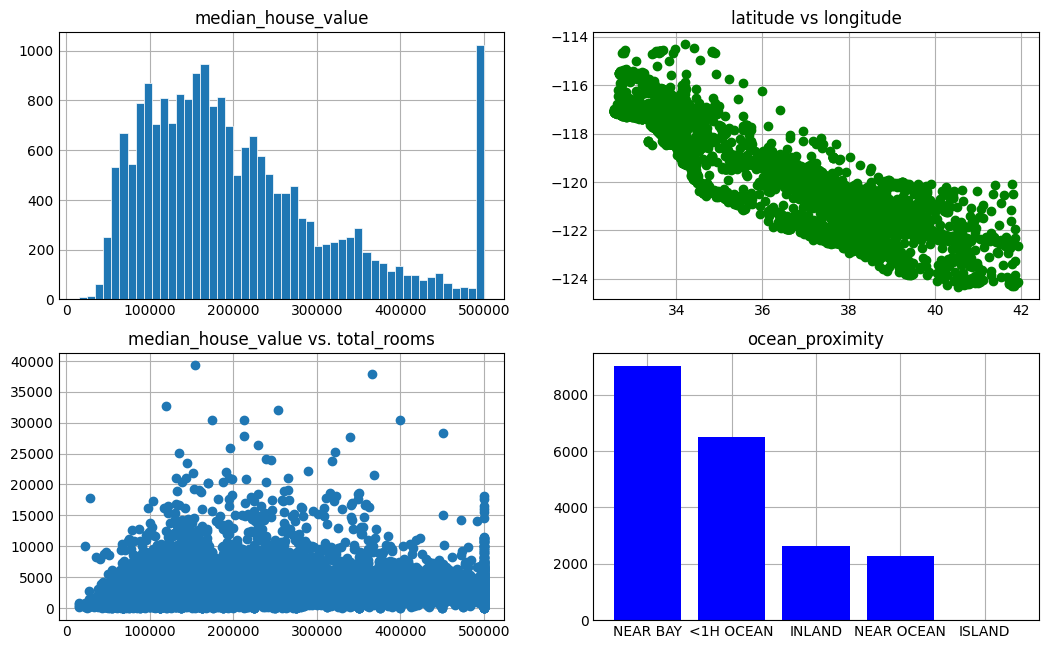

In [24]:
plotGraphs(data)

In [25]:
# Para ver boxplots de cada serie de datos numéricos
def plotBoxplots(data, figsize=(16, 6)):
    """
    Muestra un boxplot para cada valor numérico de 'data'
    """

    # Creamos los ejes de la figura
    plot_data = data.select_dtypes(include="number")
    rows = 2
    cols = (len(plot_data.columns) + 1) // rows

    fig, axs = plt.subplots(nrows=rows, ncols=cols, figsize=figsize, layout="constrained")
    # Aplanamos la matriz para recorrer cada uno de sus valores (no nos interesan sus índices x,y)
    axs = axs.flatten()

    for i, col in enumerate(plot_data.columns):
        ax = axs[i]
        ax.set_title(col)
        data = np.array(plot_data[col])
        ax.boxplot(data, showmeans=True, showfliers=True)

    # Ocultamos las celdas vacías (si las hay)
    for j in range(i + 1, len(axs)):
        axs[j].set_visible(False)

    plt.show()


# Para ver bar plots de cada serie de datos numéricos
def plotBarPlots(data, figsize=(16, 6)):
    """
    Muestra un boxplot para cada valor numérico de 'data'
    """

    # Creamos los ejes de la figura
    plot_data = data.select_dtypes(include="number")
    rows = 2
    cols = (len(plot_data.columns) + 1) // rows

    fig, axs = plt.subplots(
        nrows=rows, ncols=cols, figsize=figsize, layout="constrained"
    )
    # Aplanamos la matriz para recorrer cada uno de sus valores (no nos interesan sus índices x,y)
    axs = axs.flatten()

    for i, col in enumerate(plot_data.columns):
        ax = axs[i]
        ax.set_title(col)
        data = np.array(plot_data[col])
        ax.hist(data, bins=50, edgecolor="white")

    # Ocultamos las celdas vacías (si las hay)
    for j in range(i + 1, len(axs)):
        axs[j].set_visible(False)

    plt.show()

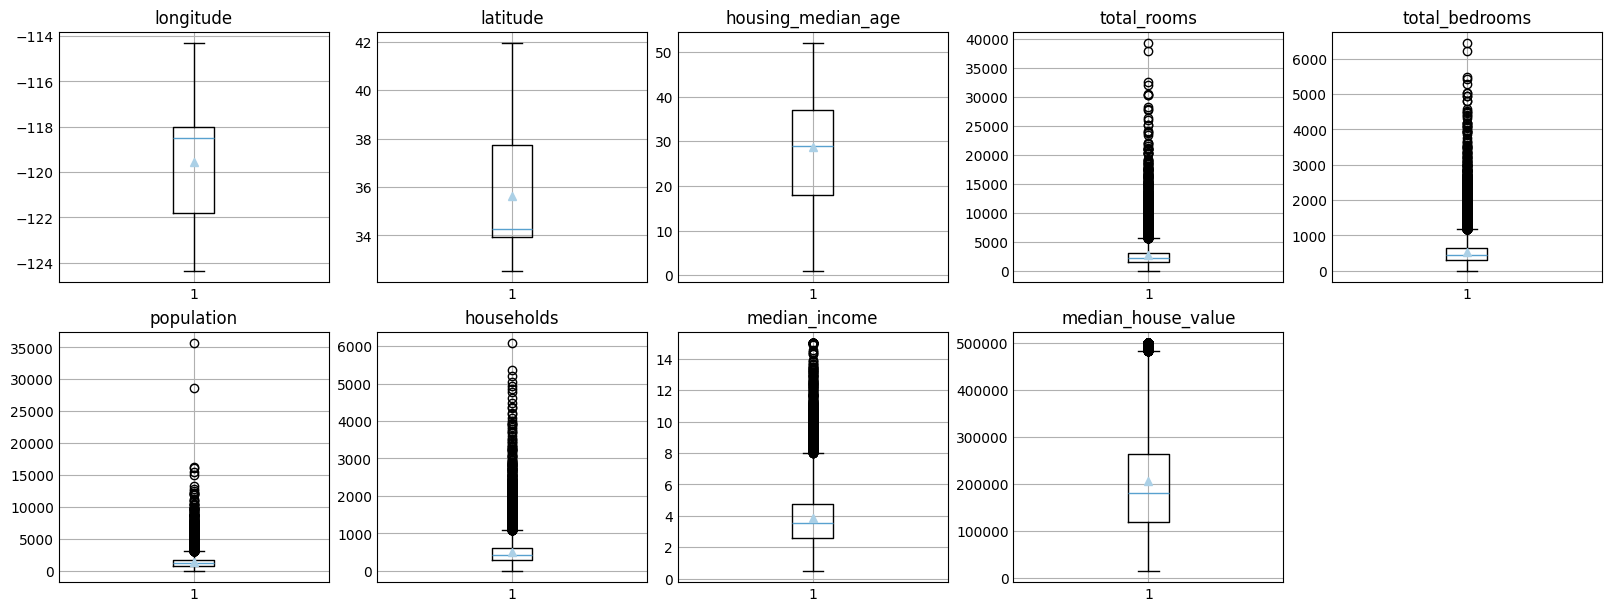

In [26]:
plotBoxplots(data)
# plotBarPlots(data)

### Eliminación de outliers de todas las variables
Primero, creamos nuevas columnas con las variables relativas a 'household'. Por ejemplo, en un bloque de casas con 500 habitaciones es importante conocer si hay 500 residentes/habitantes o 1000

Después, para cada variable numérica, miramos cada uno de sus valores y eliminamos los que estén por muy alejados de la media (1.5 * RangoIntercuartil)

In [27]:
# --- Creación de columnas con valores relativos ---

# 'total_rooms', 'total_bedrooms' y 'population' relativo a 'households'
data["rooms_per_household"] = data["total_rooms"] / data["households"]
data["bedrooms_per_household"] = data["total_bedrooms"] / data["households"]
data["population_per_household"] = data["population"] / data["households"]
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_household,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,1.023810,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.971880,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,1.073446,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,1.073059,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,1.081081,2.181467


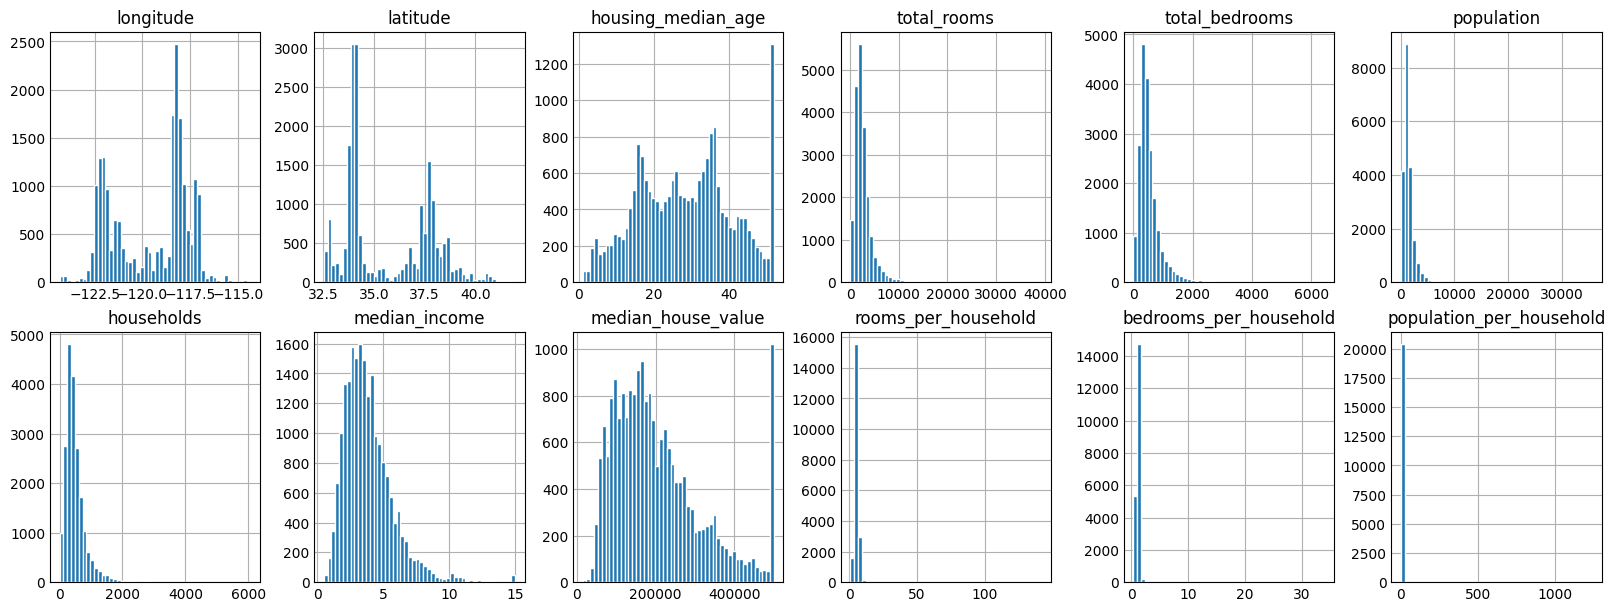

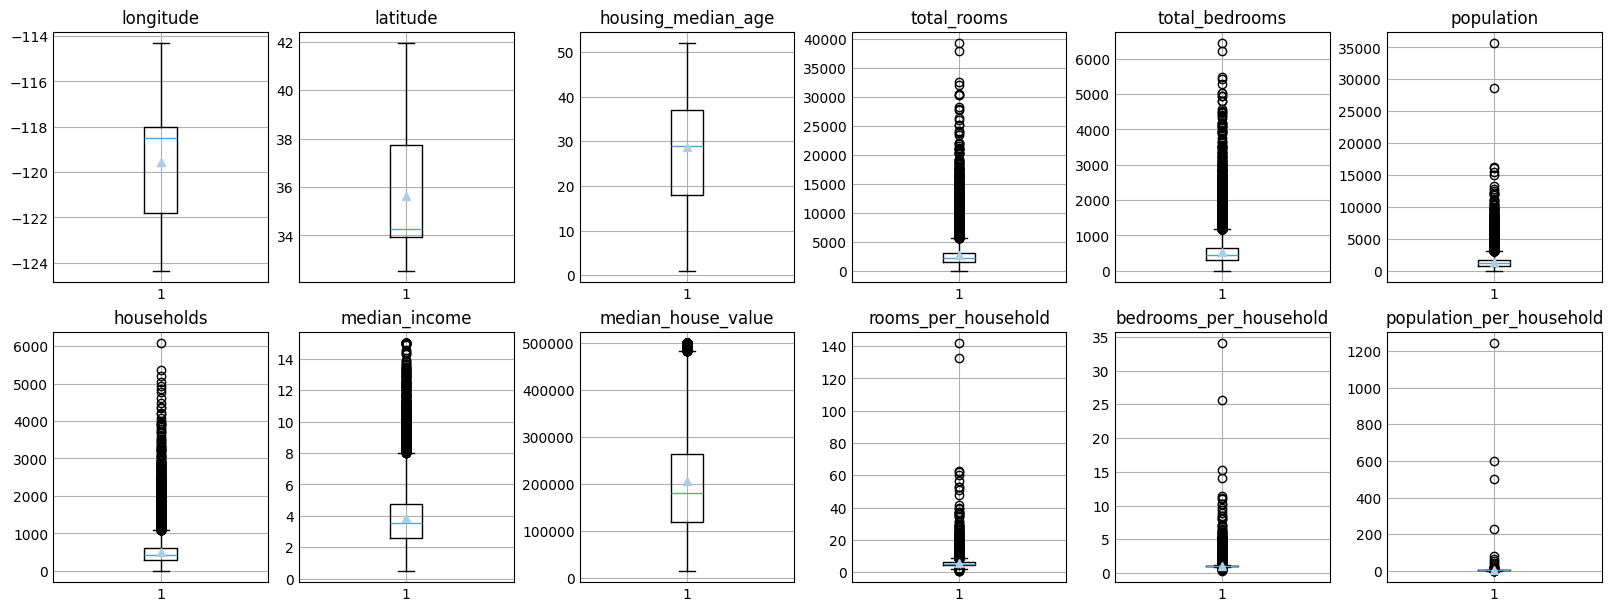

In [28]:
# Ahora ya podemos ver mejor las variables
plotBarPlots(data)
plotBoxplots(data)

In [29]:
# Imprimimos por pantalla varios valores para ver como se distribuyen los datos
column = data["rooms_per_household"]
column = data["population_per_household"]
print(
    column.min(),
    column.median(),
    column.mean(),
    column.max(),
)
print(column.std())
# Columna de 'rooms_per_household' ordenada en orden descendente
print(
    data.sort_values("rooms_per_household", ascending=False).loc[
        :, "rooms_per_household"
    ]
)

0.6923076923076923 2.817582417582418 3.0715328511910425 1243.3333333333333
10.438269197563635
1914     141.909091
1979     132.533333
12447     62.422222
1913      61.812500
11862     59.875000
            ...    
17820      1.130435
14818      1.130435
3126       1.000000
8219       0.888889
5916       0.846154
Name: rooms_per_household, Length: 20433, dtype: float64


### Eliminación de datos fuera de rango
Primero, quitamos las casas con 'median_house_value' igual a 500001 y las casas con 'housing_median_age' iguales a 52 (son valores mal etiquetados, están aproximados a ese valor como 'valor máximo')

Luego, eliminamos outliers de las variables relativas

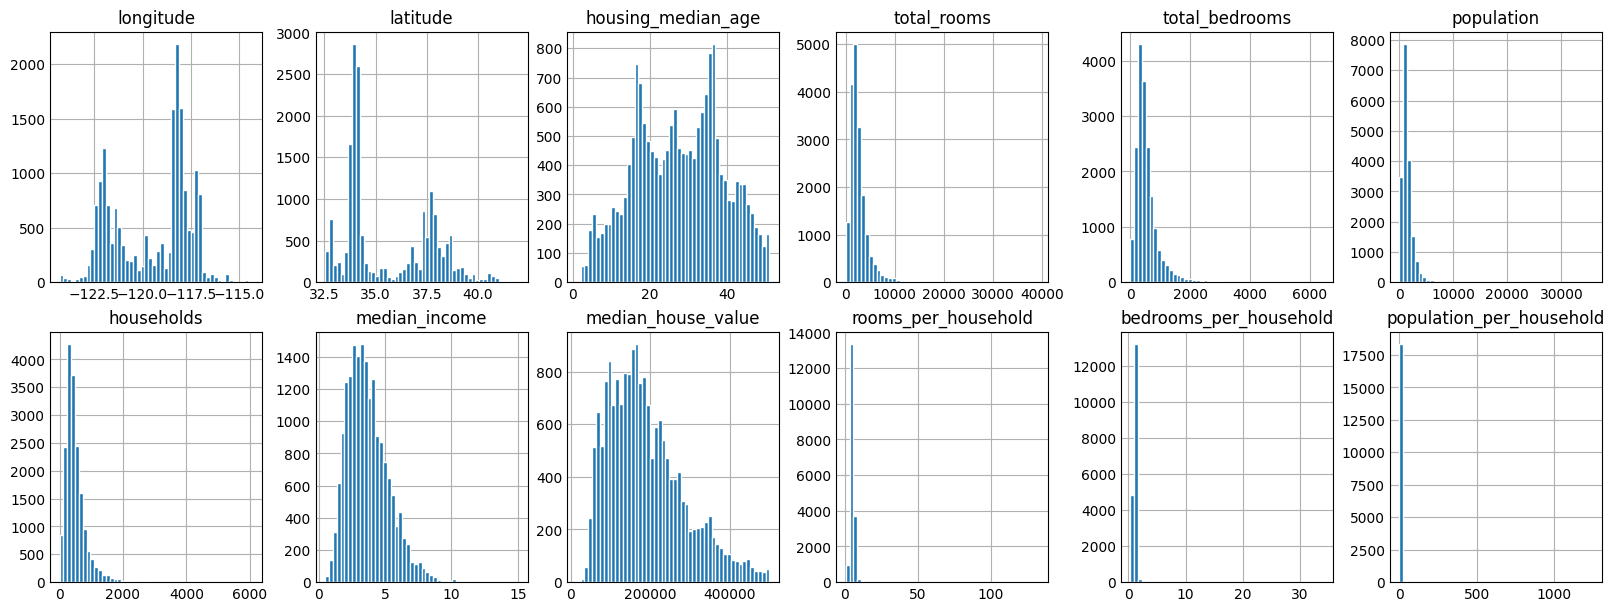

In [30]:
# -- Quitamos las casas con 'median_house_value' igual a 500001 y las casas con 'median_house_age' iguales a 52
data = data[data.median_house_value < 500001]
data = data[data.housing_median_age < 52]
plotBarPlots(data)

In [31]:
# --- Eliminación de outliers ---
# A partir de las nuevas variables relativas, se eliminan los valores muy alejados de la media

separacion_maxima = 1.5 # 2.5 también sirve
data_sin_outliers = data.copy()

# Solo nos interesan las variables numéricas, no categóricas
variables_numericas = data_sin_outliers.select_dtypes(include="number")
print(list(variables_numericas.columns))

print(" COLUMN NAME  |  Q1  |  Q3  |  RI")
for col in variables_numericas.columns:
    columnName = variables_numericas[col]
    # print("\n", col, "\n", column)

    # IQR o RI: Rango intercuartil
    Q1, Q3 = variables_numericas[col].quantile([0.25, 0.75])
    RI = Q3 - Q1
    print(col, Q1, Q3, RI)

    # Eliminamos los outliers por encima del valor especificado
    """ data_limpio = data[(data["columna"] >= Q1 - 1.5 * RI) & (data["columna"] <= Q3 + 1.5 * RI)] """
    data_sin_outliers = data_sin_outliers[
        (data_sin_outliers[col] >= Q1 - separacion_maxima * RI)
        & (data_sin_outliers[col] <= Q3 + separacion_maxima * RI)
    ]

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'rooms_per_household', 'bedrooms_per_household', 'population_per_household']
 COLUMN NAME  |  Q1  |  Q3  |  RI
longitude -121.55 -117.97 3.5799999999999983
latitude 33.92 37.67 3.75
housing_median_age 17.0 36.0 19.0
total_rooms 1458.0 3182.0 1724.0
total_bedrooms 300.0 659.0 359.0
population 811.0 1779.0 968.0
households 284.0 614.0 330.0
median_income 2.537 4.6167 2.0797
median_house_value 115400.0 243200.0 127800.0
rooms_per_household 4.431929638753942 5.989600605579987 1.557670966826045
bedrooms_per_household 1.0057581786030063 1.09939704333297 0.09363886472996374
population_per_household 2.4688646259086706 3.3202913445803857 0.851426718671715


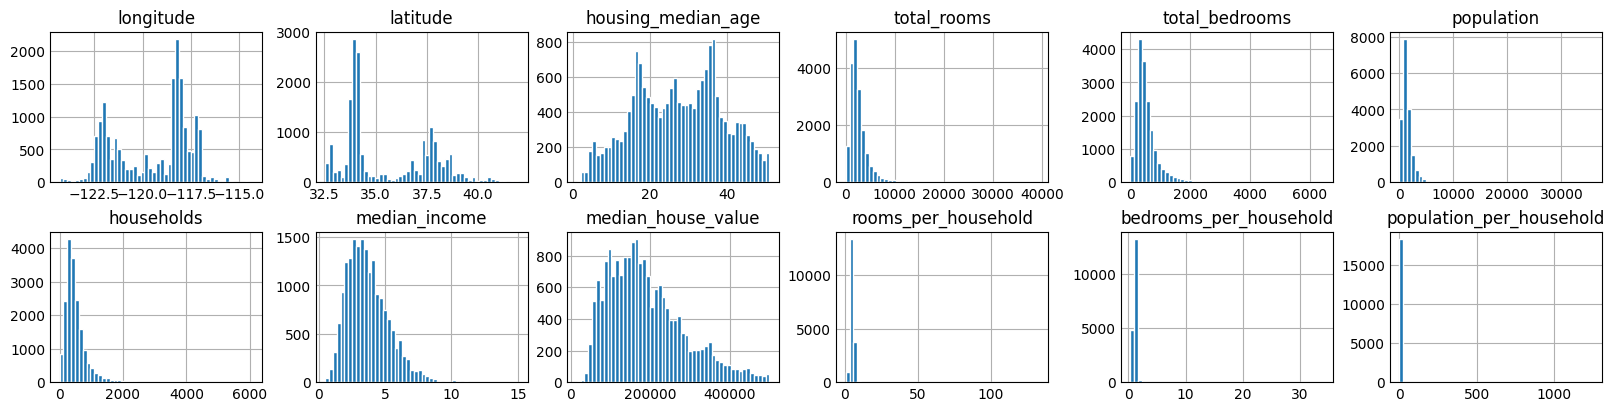

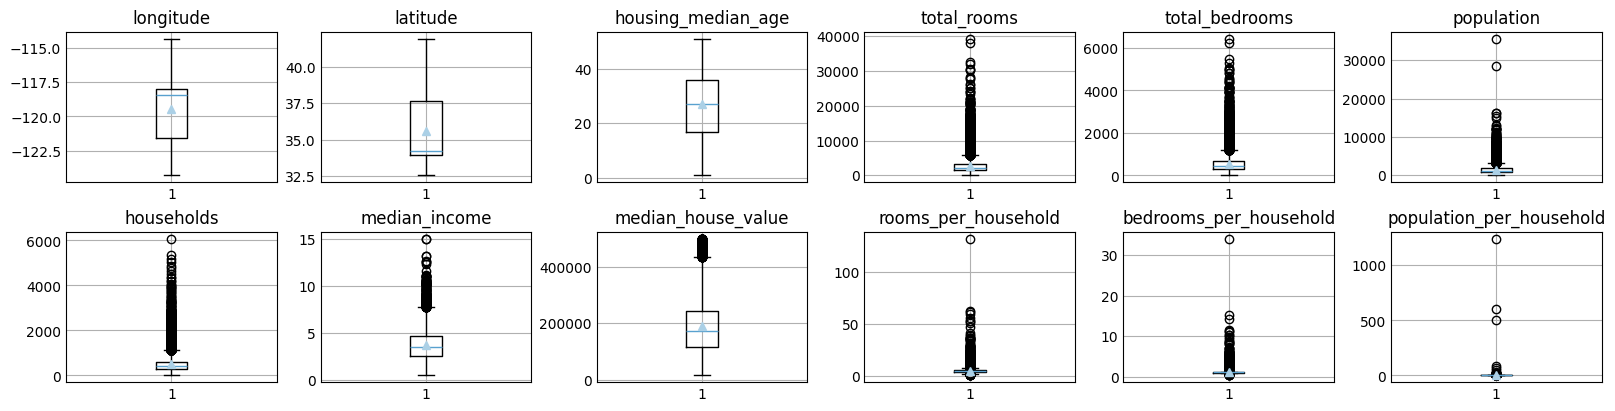


DATOS SIN OUTLIERS


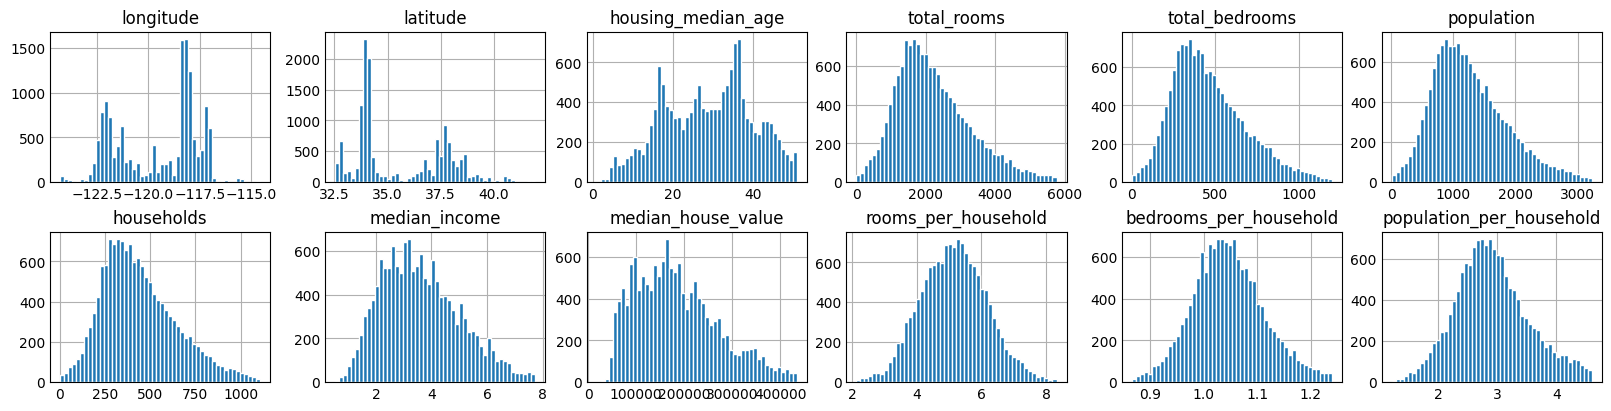

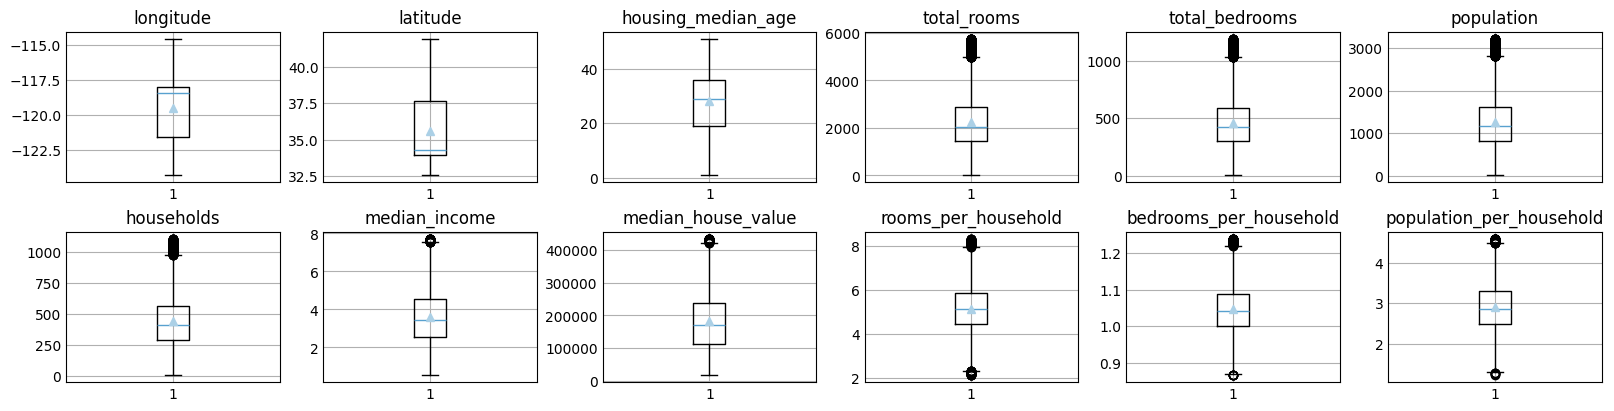

In [32]:
# Volvemos a visualizar los datos
plotBarPlots(data, figsize=(16, 4))
plotBoxplots(data, figsize=(16, 4))
print("\nDATOS SIN OUTLIERS")
plotBarPlots(data_sin_outliers, figsize=(16, 4))
plotBoxplots(data_sin_outliers, figsize=(16, 4))

In [33]:
# Volvemos a guardar los nuevos datos como 'data'
data = data_sin_outliers.copy()
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_household,population_per_household
count,14558.000000,14558.000000,14558.000000,14558.000000,14558.000000,14558.000000,14558.000000,14558.000000,14558.000000,14558.000000,14558.000000,14558.000000
mean,-119.537763,35.609848,28.299423,2237.978843,461.606127,1258.240280,439.777305,3.620133,183836.378623,5.151522,1.046123,2.912683
std,1.966415,2.142901,11.079998,1081.443381,220.855351,598.881472,205.151205,1.407257,86626.229557,1.020861,0.066913,0.621937
min,-124.300000,32.540000,1.000000,6.000000,2.000000,5.000000,2.000000,0.536000,17500.000000,2.133929,0.865613,1.215873
25%,-121.600000,33.920000,19.000000,1461.250000,299.000000,820.000000,289.000000,2.541975,114300.000000,4.436503,1.000000,2.486454
50%,-118.480000,34.250000,29.000000,2054.000000,423.000000,1164.000000,406.000000,3.461200,171300.000000,5.147133,1.042219,2.857865
75%,-118.010000,37.670000,36.000000,2866.750000,594.000000,1614.000000,564.000000,4.547225,237500.000000,5.839889,1.088109,3.287547
max,-114.570000,41.950000,51.000000,5764.000000,1197.000000,3226.000000,1107.000000,7.736000,434800.000000,8.320442,1.239796,4.597403


# Notas aparte

In [34]:
# NOTAS APARTE
# house = data.iloc[0, :] # Para mirar casa por casa
# house